In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

aashmadangol_plant_diseases_classification_dataset_path = kagglehub.dataset_download('aashmadangol/plant-diseases-classification-dataset')

print('Data source import complete.')


**1. IMPORTS**

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

**2. GPU CHECK**

In [ ]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**3. DATASET PATH**

In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset"

train_dir = os.path.join(DATASET_ROOT, "train", "train")
val_dir   = os.path.join(DATASET_ROOT, "val", "val")
test_dir  = os.path.join(DATASET_ROOT, "test", "test")

print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)

Train dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/train/train
Val dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/val/val
Test dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/test/test


**4. SAFE IMAGE COUNT**

In [ ]:
def count_images(path):
    total = 0
    class_counts = {}

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            class_counts[cls] = n
            total += n

    return total, class_counts

train_total, train_counts = count_images(train_dir)

print("Train images:", train_total)
print("Classes:", len(train_counts))

Train images: 67507
Classes: 38


**Visualization**

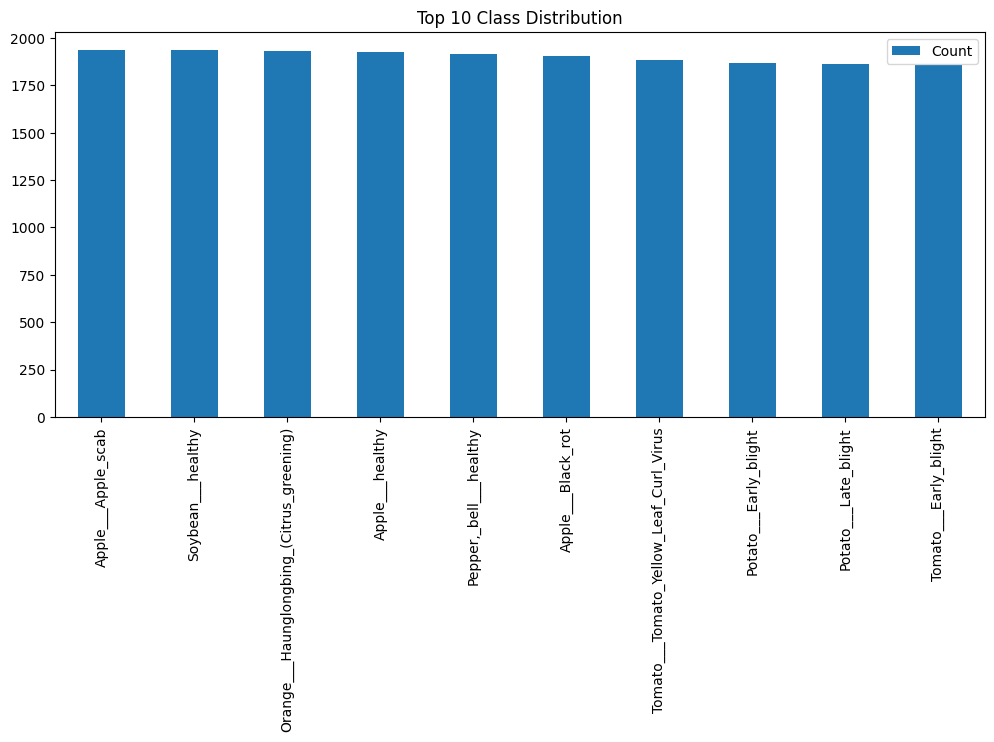

In [ ]:
df_counts = pd.DataFrame.from_dict(train_counts, orient='index', columns=['Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)

df_counts.head(10).plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Class Distribution")
plt.show()

**5. SAFE CONFIG**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8   # 🔥 prevents RAM crash

**6. LOAD DATASET**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 67507 files belonging to 38 classes.


I0000 00:00:1778739272.799136      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778739272.805094      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25364 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sep

**7. PERFORMANCE**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds   = test_ds.prefetch(AUTOTUNE)

**8. SHOW SAMPLE IMAGES**

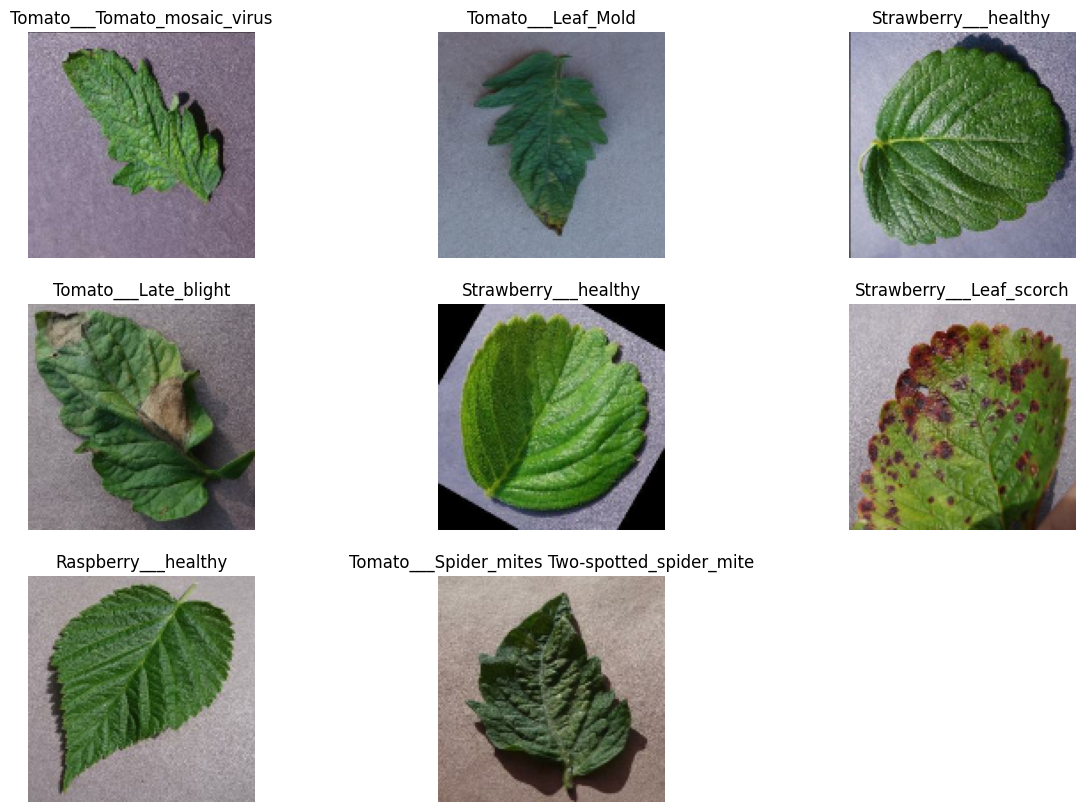

In [ ]:
plt.figure(figsize=(15,10))

for images, labels in train_ds.take(1):
    n = min(9, images.shape[0])  # 🔥 prevents crash

    for i in range(n):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# **PART A — BASELINE CNN**

**9. MODEL**

In [ ]:
baseline_model = models.Sequential([
    layers.Input(shape=(128,128,3)),   # FIXED (no warning)

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

**10. COMPILE**

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**11. TRAIN**

In [ ]:
start = time.time()

history_base = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("Time:", time.time() - start)

Epoch 1/10


I0000 00:00:1778739366.765838     139 service.cc:152] XLA service 0x788e74006d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778739366.765876     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778739366.765880     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778739367.144850     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 06:16:08.724960: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 06:16:08.868370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  24/8439 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - accuracy: 0.0066 - loss: 3.6917    

I0000 00:00:1778739370.663987     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 96s 11ms/step - accuracy: 0.5549 - loss: 1.5430 - val_accuracy: 0.8982 - val_loss: 0.3242
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.8894 - loss: 0.3511 - val_accuracy: 0.9119 - val_loss: 0.2831
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9302 - loss: 0.2109 - val_accuracy: 0.9348 - val_loss: 0.2134
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9469 - loss: 0.1637 - val_accuracy: 0.9651 - val_loss: 0.1147
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9594 - loss: 0.1335 - val_accuracy: 0.9491 - val_loss: 0.1896
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9643 - loss: 0.1217 - val_accuracy: 0.9559 - val_loss: 0.1847
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9656 - loss: 0.1155 - val_accuracy: 0.9509 - val_loss: 0.2395
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9692 - loss: 0.1076 - va

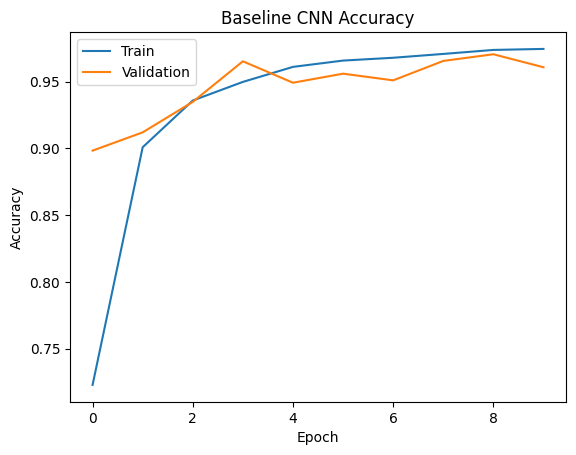

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

**Training Visualization**

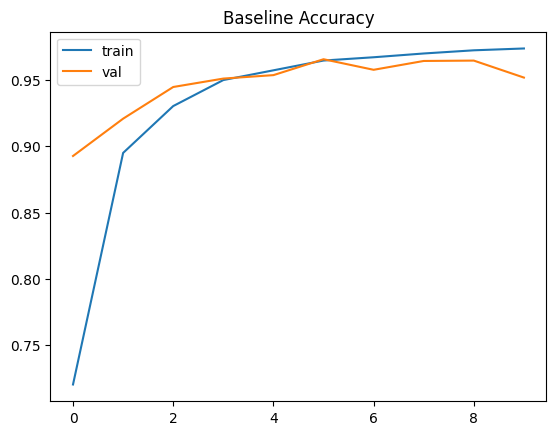

In [ ]:
plt.plot(history_base.history['accuracy'], label='train')
plt.plot(history_base.history['val_accuracy'], label='val')
plt.title("Baseline Accuracy")
plt.legend()
plt.show()

**LOSS PLOT**

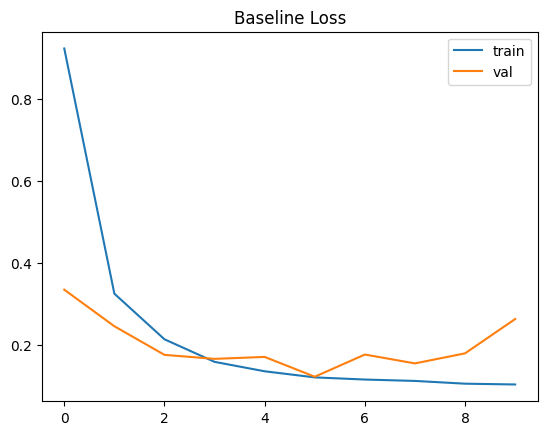

In [ ]:
plt.plot(history_base.history['loss'], label='train')
plt.plot(history_base.history['val_loss'], label='val')
plt.title("Baseline Loss")
plt.legend()
plt.show()

**PART A — DEEP CNN**

In [ ]:
deep_model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,830 (25.00 MB)

 Trainable params: 6,553,830 (25.00 MB)

 Non-trainable params: 0 (0.00 B)

**TRAIN DEEP MODEL**

In [ ]:
history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.3485 - loss: 2.3005 - val_accuracy: 0.8091 - val_loss: 0.6249
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.7430 - loss: 0.8389 - val_accuracy: 0.8902 - val_loss: 0.3436
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.8197 - loss: 0.5899 - val_accuracy: 0.9158 - val_loss: 0.2777
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.8539 - loss: 0.4807 - val_accuracy: 0.9358 - val_loss: 0.2230
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.8727 - loss: 0.4145 - val_accuracy: 0.9314 - val_loss: 0.2257
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.8923 - loss: 0.3666 - val_accuracy: 0.9596 - val_loss: 0.1288
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.9028 - loss: 0.3319 - val_accuracy: 0.9662 - val_loss: 0.1074
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.9081 - loss: 0

**Visualization of accuracy and loss**

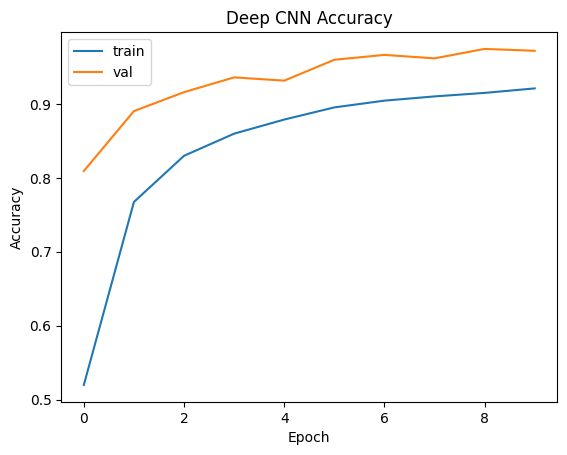

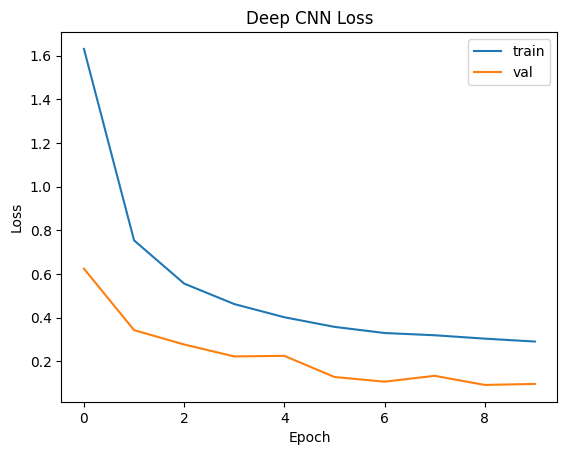

In [ ]:
plt.plot(history_deep.history['accuracy'], label='train')
plt.plot(history_deep.history['val_accuracy'], label='val')

plt.title("Deep CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()
plt.plot(history_deep.history['loss'], label='train')
plt.plot(history_deep.history['val_loss'], label='val')

plt.title("Deep CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**PREDICTIONS**

In [ ]:
y_true_base = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_base = np.argmax(baseline_model.predict(val_ds), axis=1)

3171/3171 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


**REPORT**

In [ ]:
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.04      0.04      0.04       727
                                 Apple___Black_rot       0.05      0.05      0.05       713
                          Apple___Cedar_apple_rust       0.03      0.03      0.03       638
                                   Apple___healthy       0.04      0.04      0.04       721
                               Blueberry___healthy       0.03      0.03      0.03       660
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       609
                 Cherry_(including_sour)___healthy       0.03      0.03      0.03       660
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.02      0.02      0.02       595
                       Corn_(maize)___Common_rust_       0.04      0.04      0.04       684
               Corn_(maize)___Northern_Leaf_Blight       0.03      0.02      0.

# **SGD vs ADAM**

In [ ]:
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
sgd_model.summary()

history_sgd = sgd_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 72s 8ms/step - accuracy: 0.1869 - loss: 2.9508 - val_accuracy: 0.6821 - val_loss: 1.0190
Epoch 2/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.6352 - loss: 1.2038 - val_accuracy: 0.8125 - val_loss: 0.6087
Epoch 3/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.7814 - loss: 0.7135 - val_accuracy: 0.8975 - val_loss: 0.3500
Epoch 4/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.8422 - loss: 0.5094 - val_accuracy: 0.5924 - val_loss: 1.8671
Epoch 5/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.8845 - loss: 0.3699 - val_accuracy: 0.9480 - val_loss: 0.1619


# **ABLATION STUDY**

In [ ]:
ablation_model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


ablation_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 73s 8ms/step - accuracy: 0.5880 - loss: 1.4360 - val_accuracy: 0.8742 - val_loss: 0.4060
Epoch 2/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.8903 - loss: 0.3408 - val_accuracy: 0.9536 - val_loss: 0.1444
Epoch 3/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.9416 - loss: 0.1777 - val_accuracy: 0.9639 - val_loss: 0.1236
Epoch 4/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.9631 - loss: 0.1188 - val_accuracy: 0.9638 - val_loss: 0.1304
Epoch 5/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.9713 - loss: 0.0980 - val_accuracy: 0.9704 - val_loss: 0.1196


# **PART B — TRANSFER LEARNING**

**12. MOBILE NET V2**

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**13. DATA**

In [ ]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
).prefetch(AUTOTUNE)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
).prefetch(AUTOTUNE)

Found 67507 files belonging to 38 classes.
Found 25364 files belonging to 38 classes.


**14. MODEL**

In [ ]:
base_model.trainable = False

transfer_model = models.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

**15. COMPILE**

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**16. TRAIN**

In [ ]:
history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10
)

Epoch 1/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 97s 42ms/step - accuracy: 0.7417 - loss: 0.9080 - val_accuracy: 0.9491 - val_loss: 0.1578
Epoch 2/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9196 - loss: 0.2451 - val_accuracy: 0.9584 - val_loss: 0.1260
Epoch 3/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9342 - loss: 0.1920 - val_accuracy: 0.9619 - val_loss: 0.1087
Epoch 4/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 75s 36ms/step - accuracy: 0.9412 - loss: 0.1707 - val_accuracy: 0.9709 - val_loss: 0.0852
Epoch 5/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9491 - loss: 0.1484 - val_accuracy: 0.9729 - val_loss: 0.0795
Epoch 6/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9543 - loss: 0.1286 - val_accuracy: 0.9821 - val_loss: 0.0548
Epoch 7/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9579 - loss: 0.1209 - val_accuracy: 0.9785 - val_loss: 0.0601
Epoch 8/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 75s 36ms/step - accuracy: 0.9605 -

**Visualization**

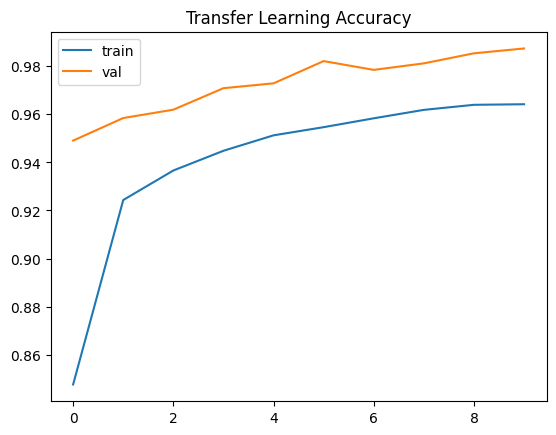

In [ ]:
plt.plot(history_transfer.history['accuracy'], label='train')
plt.plot(history_transfer.history['val_accuracy'], label='val')

plt.title("Transfer Learning Accuracy")
plt.legend()
plt.show()

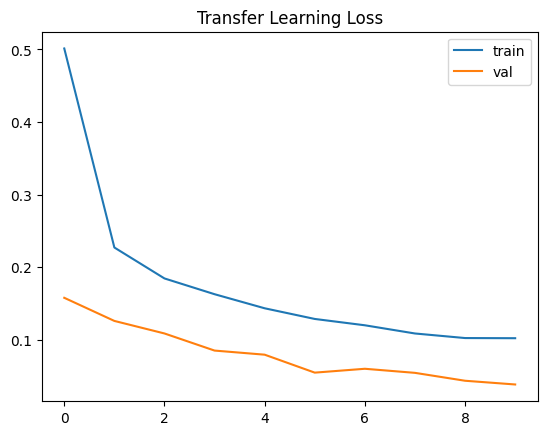

In [ ]:
plt.plot(history_transfer.history['loss'], label='train')
plt.plot(history_transfer.history['val_loss'], label='val')

plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

**FINAL PREDICTION**

In [ ]:
import numpy as np

y_true_tl = np.concatenate([y for x, y in val_ds_tl], axis=0)
y_pred_tl = np.argmax(transfer_model.predict(val_ds_tl), axis=1)

793/793 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step


In [ ]:
from sklearn.metrics import classification_report

print("TRANSFER LEARNING CLASSIFICATION REPORT")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

TRANSFER LEARNING CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      0.99       727
                                 Apple___Black_rot       1.00      1.00      1.00       713
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       638
                                   Apple___healthy       0.98      1.00      0.99       721
                               Blueberry___healthy       1.00      0.99      1.00       660
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       609
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       660
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.97      0.97       595
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       684
               Corn_(maize)___Northern_

**CONFUSION MATRIX**

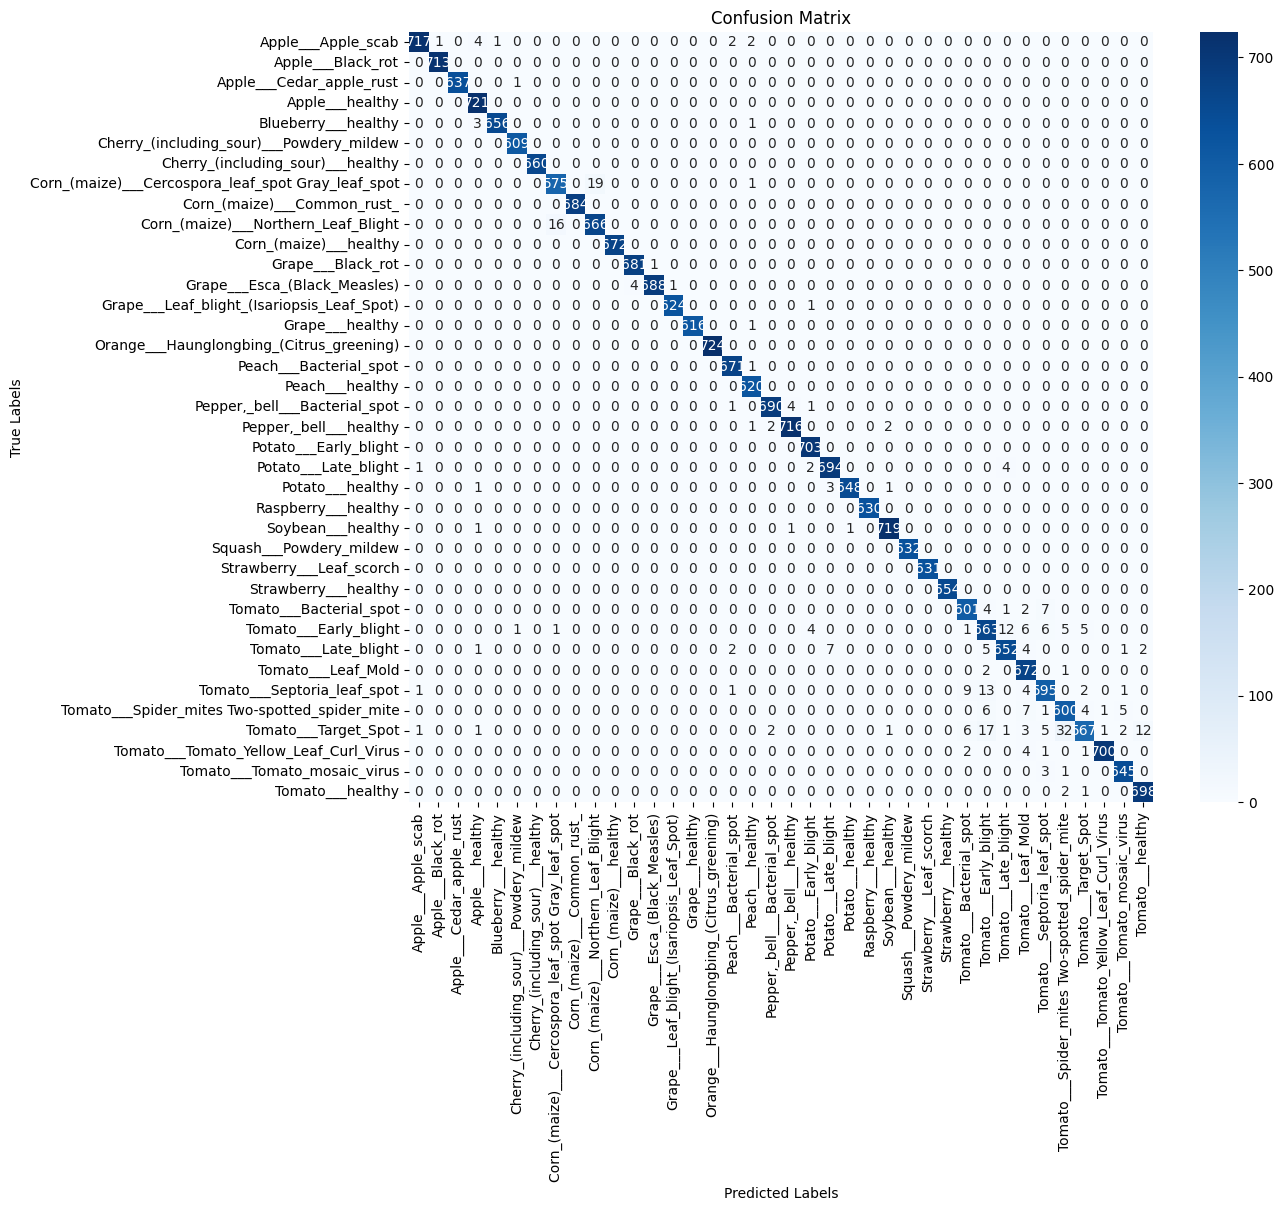

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

**FINAL MODEL COMPARISON**

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "Deep CNN", "Transfer Learning"],
    "Accuracy": [
        max(history_base.history['val_accuracy']),
        max(history_deep.history['val_accuracy']),
        max(history_transfer.history['val_accuracy'])
    ]
})

print(results)

               Model  Accuracy
0           Baseline  0.970431
1           Deep CNN  0.974255
2  Transfer Learning  0.987384


**VISUAL COMPARISON**

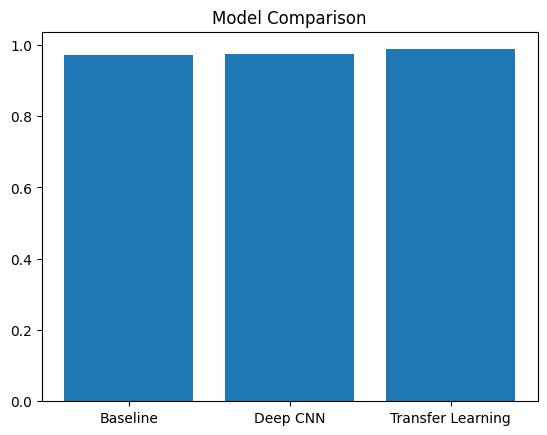

In [ ]:
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.show()

**Baseline**

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_ds)
print("Baseline Test Accuracy:", test_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9077 - loss: 0.6076
Baseline Test Accuracy: 0.8988732099533081


**Deep Model**

In [ ]:
test_loss_deep, test_acc_deep = deep_model.evaluate(test_ds)
print("Deep CNN Test Accuracy:", test_acc_deep)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9139 - loss: 0.3265
Deep CNN Test Accuracy: 0.9110516905784607


**Transfer Learning**

In [ ]:
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds)
print("Transfer Learning Test Accuracy:", test_acc_tl)

2026-05-14 07:31:01.077218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 07:31:01.212981: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2189/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8045 - loss: 1.4406

2026-05-14 07:31:25.133136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 07:31:25.269302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 07:31:25.405001: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.8045 - loss: 1.4408
Transfer Learning Test Accuracy: 0.7904052138328552


In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "Deep CNN", "Transfer Learning"],
    "Test Accuracy": [test_acc, test_acc_deep, test_acc_tl]
})

print(results)

               Model  Test Accuracy
0           Baseline       0.898873
1           Deep CNN       0.911052
2  Transfer Learning       0.790405
